# Pharma Problem Statement

## Phase 1: Data Inspection

In [1]:
!pip install -q wolta

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import wolta

import os
import warnings

from sklearn.preprocessing import LabelEncoder
from wolta.data_tools import col_types, seek_null

In [3]:
warnings.filterwarnings('ignore')

In [4]:
for dirpath, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirpath, filename))

/kaggle/input/datasets/vankapgrover/pharma-dataset/train.csv
/kaggle/input/datasets/vankapgrover/pharma-dataset/test.csv


### Loading the data

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/vankapgrover/pharma-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/vankapgrover/pharma-dataset/test.csv")

In [6]:
print(train_df.shape)
train_df.head()

(22083, 45)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [7]:
print(test_df.shape)
test_df.head()

(9465, 43)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,PID0x4175,6,No,Yes,No,No,4.981655,Charles,NaN,Kore,...,-99,2,Multiple,-99.000000,slightly abnormal,True,True,True,True,True
1,PID0x21f5,10,Yes,No,NaN,Yes,5.118890,Catherine,NaN,Homero,...,Yes,-99,Multiple,8.179584,normal,False,False,False,True,False
2,PID0x49b8,5,No,NaN,No,No,4.876204,James,NaN,Danield,...,No,0,Singular,-99.000000,slightly abnormal,False,False,True,True,False
3,PID0x2d97,13,No,Yes,Yes,No,4.687767,Brian,NaN,Orville,...,Yes,-99,Singular,6.884071,normal,True,False,True,False,True
4,PID0x58da,5,No,NaN,NaN,Yes,5.152362,Gary,NaN,Issiah,...,No,-99,Multiple,6.195178,normal,True,True,True,True,False


Let's now see the different types of Genetic Orders & Disorder Subclasses Present

In [8]:
GENETIC_DISORDER_COL_NAME = "Genetic Disorder"
DISORDER_SUBCLASS_COL_NAME = "Disorder Subclass"

In [9]:
genetic_disorder_classes = train_df[GENETIC_DISORDER_COL_NAME].dropna().unique()
for disorder in genetic_disorder_classes:
    print(disorder)

Mitochondrial genetic inheritance disorders
Multifactorial genetic inheritance disorders
Single-gene inheritance diseases


We have 3 Main Disorders

In [10]:
disorder_subclasses = train_df[DISORDER_SUBCLASS_COL_NAME].dropna().unique()
print(f"Total number of subclasses: {len(disorder_subclasses)}")
print()
for subclass in disorder_subclasses:
    print(subclass)

Total number of subclasses: 9

Leber's hereditary optic neuropathy
Cystic fibrosis
Diabetes
Leigh syndrome
Cancer
Tay-Sachs
Hemochromatosis
Mitochondrial myopathy
Alzheimer's


We have 9 Disorder Subclasses

In [11]:
disorder_subclasses_df = train_df[[GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME]].dropna().drop_duplicates().reset_index(drop=True)
disorder_subclasses_df

,Genetic Disorder,Disorder Subclass
0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,Multifactorial genetic inheritance disorders,Diabetes
2,Mitochondrial genetic inheritance disorders,Leigh syndrome
3,Multifactorial genetic inheritance disorders,Cancer
4,Single-gene inheritance diseases,Cystic fibrosis
5,Single-gene inheritance diseases,Tay-Sachs
6,Single-gene inheritance diseases,Hemochromatosis
7,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy
8,Multifactorial genetic inheritance disorders,Alzheimer's


So, there are 9 unique **disorder**-**subclass** combinations present in the dataset.

By the end of this phase, we came up with the following conclusions:

* **Train Dataset Shape**: **(22083, 45)**
  
* **Test Dataset Shape**: **(9465, 43)**
  
* **Unique Disorder Classes Present in the Dataset**: Mitochondrial genetic inheritance disorders, Multifactorial genetic inheritance disorders**, Single-gene inheritance diseases
  
* **Unique Disorder Subclasses Present in the Dataset**: Leber's hereditary optic neuropathy, Cystic fibrosis, Diabetes, Leigh syndrome, Cancer, Tay-Sachs, Hemochromatosis, Mitochondrial myopathy, Alzheimer's

We found 9 unique Disorder-Subclass Combinations in the Dataset:

* **Mitochondrial genetic inheritance disorders** - **Leber's hereditary optic neuropathy**
* **Multifactorial genetic inheritance disorders** - **Diabetes**
* **Mitochondrial genetic inheritance disorders** - **Leigh Syndrome**
* **Multifactorial genetic inheritance disorders** - **Cancer**
* **Single-gene inheritance diseases** - **Cystic Fibrosis**
* **Single-gene inheritance diseases** - **Tay-Sachs**
* **Single-gene inheritance diseases** - **Hemochromatosis**
* **Mitochondrial genetic inheritance disorders** - **Mitochondrial myopathy**
* **Multifactorial genetic inheritance disorders** - **Alzheimer's**

## Phase 2: Data Cleaning & Pre-Processing

### Fixing `na` Value Outputs

There are rows in the dataset where either the disorder or subclass or both the column values are `na` for certain records.

In this case we decide to do the following to not lose out on data:

* if **disorder (na) & subclass (not na)**: we infer the disorder from the subclass because every subclass is mapped to a singular and unique disorder
* if **disorder (not na) & subclass (na)**: we drop since every disorder maps to multiple subclasses and there is no certain way of knowing which one it would map to for a specific record
* if **disorder (na) & subclass (na)**: simply drop

In [12]:
both_null = train_df[GENETIC_DISORDER_COL_NAME].isnull() & train_df[DISORDER_SUBCLASS_COL_NAME].isnull()
disorder_only = train_df[GENETIC_DISORDER_COL_NAME].notna() & train_df[DISORDER_SUBCLASS_COL_NAME].isnull()
subclass_only = train_df[GENETIC_DISORDER_COL_NAME].isnull() & train_df[DISORDER_SUBCLASS_COL_NAME].notna()
 
print(f"Both targets missing: {both_null.sum()}")
print(f"Disorder present, Subclass missing: {disorder_only.sum()}")
print(f"Subclass present, Disorder missing: {subclass_only.sum()}")
print(f"Both present (usable rows): {(train_df[GENETIC_DISORDER_COL_NAME].notna() & train_df[DISORDER_SUBCLASS_COL_NAME].notna()).sum()}")
print(f"Total train rows: {len(train_df)}")

Both targets missing: 278
Disorder present, Subclass missing: 1890
Subclass present, Disorder missing: 1868
Both present (usable rows): 18047
Total train rows: 22083


In [13]:
subclass_to_disorder = {
    "Leber's hereditary optic neuropathy": "Mitochondrial genetic inheritance disorders",
    "Leigh syndrome": "Mitochondrial genetic inheritance disorders",
    "Mitochondrial myopathy": "Mitochondrial genetic inheritance disorders",
    "Diabetes": "Multifactorial genetic inheritance disorders",
    "Cancer": "Multifactorial genetic inheritance disorders",
    "Alzheimer's": "Multifactorial genetic inheritance disorders",
    "Cystic fibrosis": "Single-gene inheritance diseases",
    "Tay-Sachs": "Single-gene inheritance diseases",
    "Hemochromatosis": "Single-gene inheritance diseases",
}

In [14]:
mask_sub = train_df[GENETIC_DISORDER_COL_NAME].isnull() & train_df[DISORDER_SUBCLASS_COL_NAME].notna()
train_df.loc[mask_sub, GENETIC_DISORDER_COL_NAME] = train_df.loc[mask_sub, DISORDER_SUBCLASS_COL_NAME].map(subclass_to_disorder)
print(f"Recovered {mask_sub.sum()} rows by mapping subclass to disorder")

Recovered 1868 rows by mapping subclass to disorder


Now that we have filled rows where subclass was present and disorder was absent, we can remove rows where either subclass or disorder is `na` because that would imply that either:

* the disorder is present and subclass is `na`
* both disorder and subclass is `na`

In [15]:
before = len(train_df)
train_df = train_df.dropna(subset=[GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME])
print(f"Dropped {before - len(train_df)} rows with unrecoverable missing targets")
print(f"Train shape after cleaning targets: {train_df.shape}")

Dropped 2168 rows with unrecoverable missing targets
Train shape after cleaning targets: (19915, 45)


In [16]:
train_df["target"] = train_df[GENETIC_DISORDER_COL_NAME] + "-" + train_df[DISORDER_SUBCLASS_COL_NAME]
print(f"Unique targets: {train_df['target'].nunique()}")
print()
print(train_df['target'].value_counts())

Unique targets: 9

target
Mitochondrial genetic inheritance disorders-Leigh syndrome                         5160
Mitochondrial genetic inheritance disorders-Mitochondrial myopathy                 4405
Single-gene inheritance diseases-Cystic fibrosis                                   3448
Single-gene inheritance diseases-Tay-Sachs                                         2833
Multifactorial genetic inheritance disorders-Diabetes                              1817
Single-gene inheritance diseases-Hemochromatosis                                   1355
Mitochondrial genetic inheritance disorders-Leber's hereditary optic neuropathy     648
Multifactorial genetic inheritance disorders-Alzheimer's                            152
Multifactorial genetic inheritance disorders-Cancer                                  97
Name: count, dtype: int64


### Dropping Insignificant Columns

In [17]:
dropped_columns = ["Patient Id", "Patient First Name", "Family Name", "Father's name", "Institute Name", "Location of Institute"]

In [18]:
print(f"BEFORE: Train dropped shape: {train_df.shape}")
print(f"BEFORE: Test dropped shape:  {test_df.shape}")
train_df = train_df.drop(columns=dropped_columns)
test_df = test_df.drop(columns=dropped_columns)
print(f"AFTER: Train dropped shape: {train_df.shape}")
print(f"AFTER: Test dropped shape:  {test_df.shape}")

BEFORE: Train dropped shape: (19915, 46)
BEFORE: Test dropped shape:  (9465, 43)
AFTER: Train dropped shape: (19915, 40)
AFTER: Test dropped shape:  (9465, 37)


### Null Value Handling

Strategy:
- Numeric cols → median imputation
- Categorical cols → "Missing" as its own category
- Add a "missing count per row" feature (captures overall data completeness)

In [19]:
train_df.columns

Index(['Patient Age', 'Genes in mother's side', 'Inherited from father',
       'Maternal gene', 'Paternal gene', 'Blood cell count (mcL)',
       'Mother's age', 'Father's age', 'Status',
       'Respiratory Rate (breaths/min)', 'Heart Rate (rates/min', 'Test 1',
       'Test 2', 'Test 3', 'Test 4', 'Test 5', 'Parental consent', 'Follow-up',
       'Gender', 'Birth asphyxia',
       'Autopsy shows birth defect (if applicable)', 'Place of birth',
       'Folic acid details (peri-conceptional)',
       'H/O serious maternal illness', 'H/O radiation exposure (x-ray)',
       'H/O substance abuse', 'Assisted conception IVF/ART',
       'History of anomalies in previous pregnancies',
       'No. of previous abortion', 'Birth defects',
       'White Blood cell count (thousand per microliter)', 'Blood test result',
       'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5',
       'Genetic Disorder', 'Disorder Subclass', 'target'],
      dtype='object')

In [20]:
target_cols = [GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME, "target"]
feature_cols = [c for c in train_df.columns if c not in target_cols]

In [21]:
num_cols = ["Patient Age", "Blood cell count (mcL)", "Mother's age", "Father's age", "No. of previous abortion", "White Blood cell count (thousand per microliter)"]
cat_cols = ["Genes in mother's side", "Inherited from father", "Maternal gene", "Paternal gene", "Status", "Respiratory Rate (breaths/min)", "Heart Rate (rates/min", "Test 1", "Test 2", "Test 3", "Test 4", "Test 5", "Parental consent", "Follow-up", "Gender", "Birth asphyxia", "Autopsy shows birth defect (if applicable)", "Place of birth", "Folic acid details (peri-conceptional)", "H/O serious maternal illness", "H/O radiation exposure (x-ray)",
       "H/O substance abuse", "Assisted conception IVF/ART",
       "History of anomalies in previous pregnancies", "Birth defects", "Blood test result", "Symptom 1", "Symptom 2", "Symptom 3", "Symptom 4", "Symptom 5"]

In [22]:
print(f"Numeric features ({len(num_cols)}):")
for col in num_cols:
    null_count = train_df[col].isnull().sum()
    pct = null_count / len(train_df) * 100
    print(f"  {col}: {null_count} nulls ({pct:.1f}%)")

Numeric features (6):
  Patient Age: 1243 nulls (6.2%)
  Blood cell count (mcL): 0 nulls (0.0%)
  Mother's age: 5196 nulls (26.1%)
  Father's age: 5119 nulls (25.7%)
  No. of previous abortion: 1835 nulls (9.2%)
  White Blood cell count (thousand per microliter): 1876 nulls (9.4%)


In [23]:
print(f"\nCategorical features ({len(cat_cols)}):")
for col in cat_cols:
    null_count = train_df[col].isnull().sum()
    pct = null_count / len(train_df) * 100
    print(f"  {col}: {null_count} nulls ({pct:.1f}%)")


Categorical features (31):
  Genes in mother's side: 0 nulls (0.0%)
  Inherited from father: 263 nulls (1.3%)
  Maternal gene: 2405 nulls (12.1%)
  Paternal gene: 0 nulls (0.0%)
  Status: 0 nulls (0.0%)
  Respiratory Rate (breaths/min): 1857 nulls (9.3%)
  Heart Rate (rates/min: 1788 nulls (9.0%)
  Test 1: 1845 nulls (9.3%)
  Test 2: 1856 nulls (9.3%)
  Test 3: 1864 nulls (9.4%)
  Test 4: 1828 nulls (9.2%)
  Test 5: 1852 nulls (9.3%)
  Parental consent: 1846 nulls (9.3%)
  Follow-up: 1845 nulls (9.3%)
  Gender: 1863 nulls (9.4%)
  Birth asphyxia: 1809 nulls (9.1%)
  Autopsy shows birth defect (if applicable): 3958 nulls (19.9%)
  Place of birth: 1855 nulls (9.3%)
  Folic acid details (peri-conceptional): 1823 nulls (9.2%)
  H/O serious maternal illness: 1831 nulls (9.2%)
  H/O radiation exposure (x-ray): 1857 nulls (9.3%)
  H/O substance abuse: 1897 nulls (9.5%)
  Assisted conception IVF/ART: 1830 nulls (9.2%)
  History of anomalies in previous pregnancies: 1845 nulls (9.3%)
  Birth d

**Added missing_count metric for each row**

In [24]:
train_df['missing_count'] = train_df[feature_cols].isnull().sum(axis=1)
test_df['missing_count'] = test_df[
    [c for c in feature_cols if c in test_df.columns]
].isnull().sum(axis=1)

**Replaced `na` values with column median for numerical features**

In [25]:
median_dict = {}
 
for col in num_cols:
    if col == 'missing_count':
        continue
    
    train_nulls = train_df[col].isnull().sum()
    test_nulls = test_df[col].isnull().sum()
    
    median_val = train_df[col].median()
    median_dict[col] = median_val
    
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

**Replaced `na` values with `Missing` class for categorical features**

In [26]:
for col in cat_cols:
    train_nulls = train_df[col].isnull().sum()
    test_nulls = test_df[col].isnull().sum()
    
    train_df[col] = train_df[col].fillna("Missing")
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("Missing")

In [27]:
train_feature_nulls = train_df[feature_cols].isnull().sum().sum()
test_feature_cols = [c for c in feature_cols if c in test_df.columns]
test_feature_nulls = test_df[test_feature_cols].isnull().sum().sum()
 
print(f"Remaining nulls in train features: {train_feature_nulls}")
print(f"Remaining nulls in test features:  {test_feature_nulls}")
assert train_feature_nulls == 0, "Still have nulls in train!"
assert test_feature_nulls == 0, "Still have nulls in test!"
print("All nulls handled successfully")

Remaining nulls in train features: 0
Remaining nulls in test features:  0
All nulls handled successfully


### Encoding Categorical Columns

Labelling all categorical feature columns

In [28]:
for col in cat_cols:
    le = LabelEncoder()
    
    all_values = pd.concat([
        train_df[col].astype(str),
        test_df[col].astype(str)
    ])
    le.fit(all_values)
    
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

Labelling the target column in train dataset

In [29]:
target_le = LabelEncoder()
y = target_le.fit_transform(train_df["target"])
 
class_names = target_le.classes_
print(f"Target classes ({len(class_names)}):")

Target classes (9):


## Data Preparation (X_train, X_test)

In [30]:
X_train = train_df.drop(columns=target_cols, errors='ignore').copy()
X_train

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,Respiratory Rate (breaths/min),...,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,missing_count
0,2.0,1,1,2,0,4.760603,35.0,42.0,0,2,...,2.0,1,9.857562,1,1,1,1,1,1,10
1,4.0,1,2,1,0,4.910669,35.0,23.0,1,3,...,2.0,2,5.522560,4,1,3,1,1,0,7
2,6.0,1,1,1,0,4.893297,41.0,22.0,0,2,...,4.0,3,7.478060,4,0,1,1,1,1,4
3,12.0,1,1,2,0,4.705280,21.0,42.0,1,3,...,1.0,3,7.919321,3,0,0,1,0,0,2
4,11.0,1,1,0,1,4.720703,32.0,42.0,0,3,...,4.0,2,4.098210,1,0,0,0,0,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22078,4.0,1,2,2,0,5.258298,35.0,64.0,1,2,...,3.0,2,6.584811,3,0,0,1,0,0,3
22079,8.0,0,2,1,1,4.974220,35.0,56.0,0,2,...,2.0,2,7.041556,3,1,1,1,1,0,5
22080,8.0,1,1,2,0,5.186470,35.0,51.0,1,3,...,2.0,3,7.715464,4,0,0,0,1,3,4
22081,7.0,1,1,2,1,4.858543,19.0,42.0,0,3,...,1.0,2,8.437670,2,1,1,1,0,0,1


In [31]:
print(y)
print(len(y))

[0 6 5 ... 2 1 5]
19915


In [32]:
X_test = test_df.copy()
X_test

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,Respiratory Rate (breaths/min),...,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,missing_count
0,6,0,2,1,0,4.981655,38,61,0,3,...,2,2,-99.000000,5,4,4,4,4,4,0
1,10,1,1,0,1,5.118890,33,53,0,1,...,-99,2,8.179584,4,2,2,2,4,2,2
2,5,0,0,1,0,4.876204,48,60,1,1,...,0,3,-99.000000,5,2,2,4,4,2,2
3,13,0,2,2,0,4.687767,25,55,0,0,...,-99,3,6.884071,4,4,2,4,2,4,0
4,5,0,0,0,1,5.152362,41,38,1,3,...,-99,2,6.195178,4,4,4,4,4,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,9,1,2,0,0,4.878335,28,63,0,0,...,2,2,7.234960,2,2,4,4,4,2,2
9461,1,1,1,0,1,4.927151,37,62,1,0,...,-99,3,4.859536,2,2,4,2,4,4,2
9462,2,0,2,1,0,4.898352,24,32,1,3,...,3,0,5.696062,4,2,4,2,2,4,0
9463,13,0,2,1,0,4.804840,36,56,0,1,...,1,3,3.000000,3,4,4,4,4,4,1


## Exploratory Data Analysis

In [33]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [38]:
plot_df = train_df.copy()

### Target Distribution Check

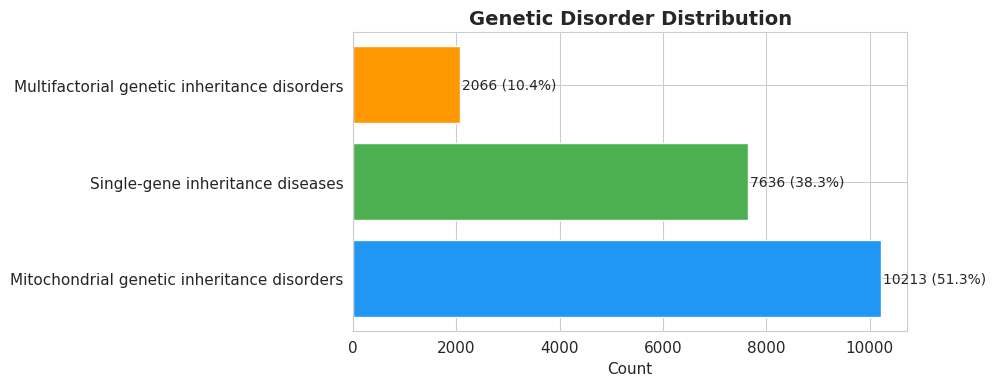

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

disorder_counts = plot_df['Genetic Disorder'].value_counts()
colors_3 = ['#2196F3', '#4CAF50', '#FF9800']
ax.barh(disorder_counts.index, disorder_counts.values, color=colors_3)
ax.set_title('Genetic Disorder Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, (val, count) in enumerate(zip(disorder_counts.index, disorder_counts.values)):
    ax.text(count + 50, i, f'{count} ({count/len(plot_df)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

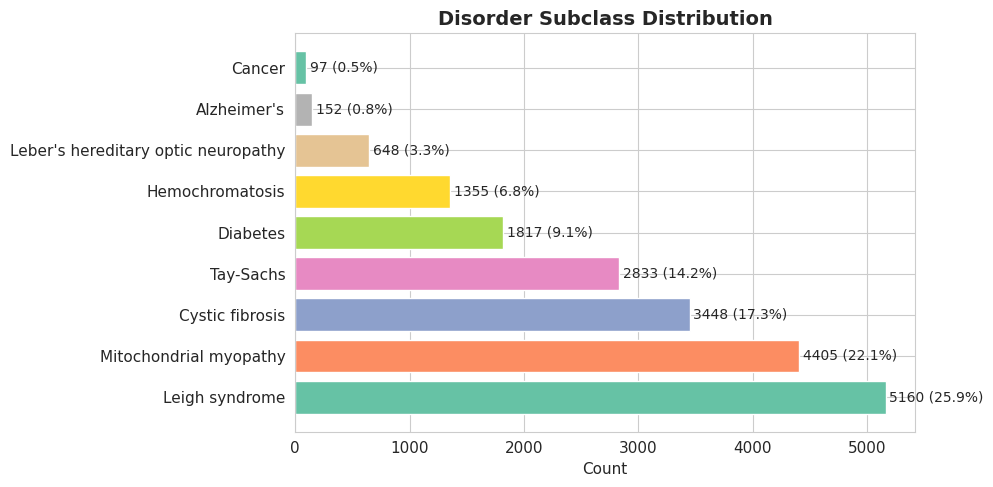

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

subclass_counts = plot_df['Disorder Subclass'].value_counts()
colors_9 = sns.color_palette("Set2", 9)
ax.barh(subclass_counts.index, subclass_counts.values, color=colors_9)
ax.set_title('Disorder Subclass Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, (val, count) in enumerate(zip(subclass_counts.index, subclass_counts.values)):
    ax.text(count + 30, i, f'{count} ({count/len(plot_df)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

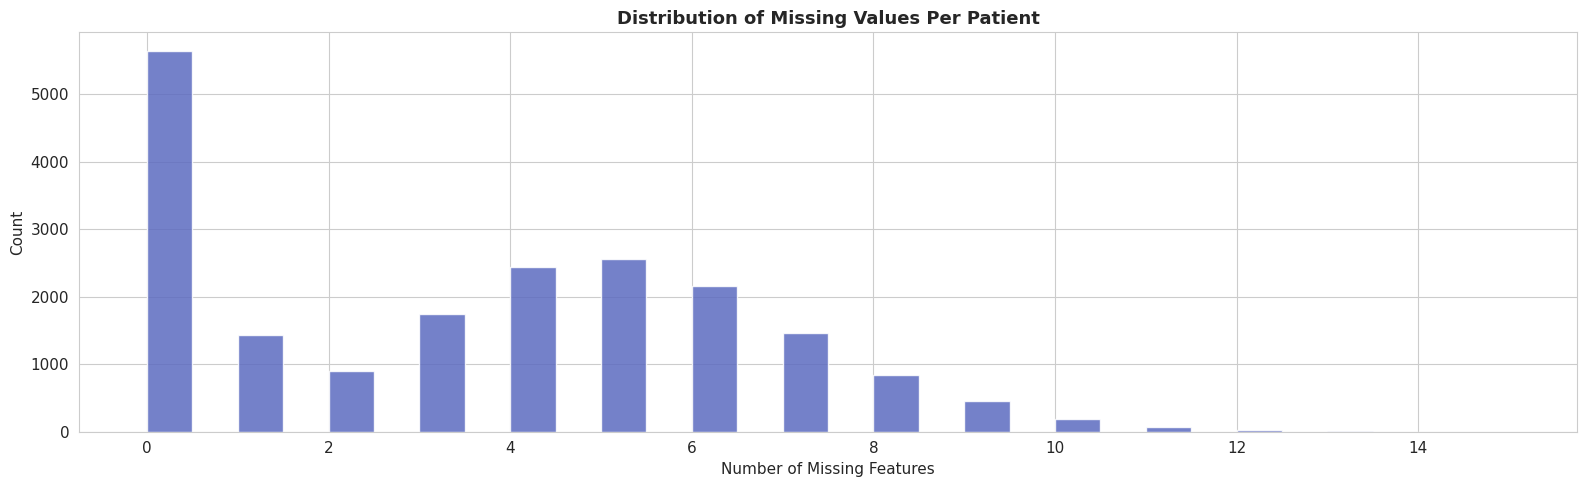

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(16, 5))
 
axes.hist(plot_df['missing_count'], bins=30, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes.set_title('Distribution of Missing Values Per Patient', fontsize=13, fontweight='bold')
axes.set_xlabel('Number of Missing Features')
axes.set_ylabel('Count')

plt.tight_layout()
plt.show()

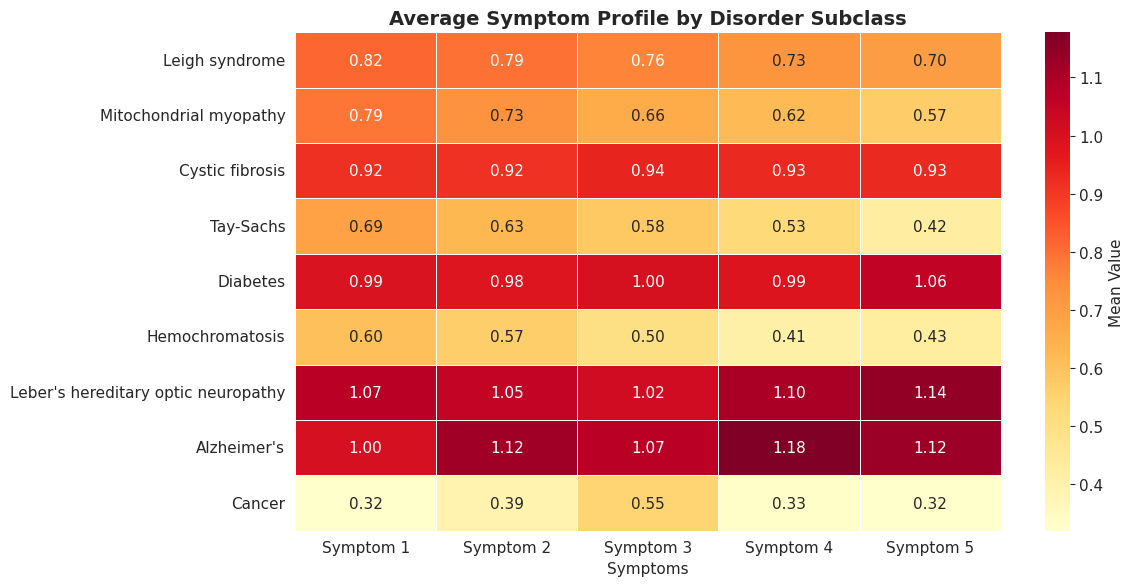

In [50]:
symptom_cols = ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
 
symptom_means = plot_df.groupby('Disorder Subclass')[symptom_cols].mean()
symptom_means = symptom_means.loc[subclass_counts.index]  # order by frequency
 
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(symptom_means, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Value'})
ax.set_title('Average Symptom Profile by Disorder Subclass', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptoms')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

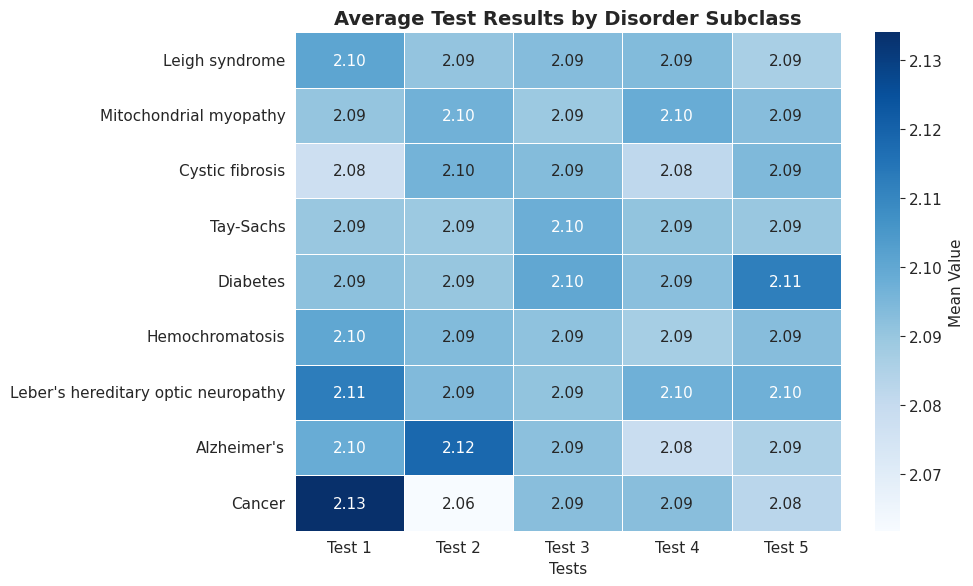

In [51]:
test_cols = ['Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5']

test_means = plot_df.groupby('Disorder Subclass')[test_cols].mean()
test_means = test_means.loc[subclass_counts.index]
 
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(test_means, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Value'})
ax.set_title('Average Test Results by Disorder Subclass', fontsize=14, fontweight='bold')
ax.set_xlabel('Tests')
ax.set_ylabel('')
plt.tight_layout()
plt.show()